# Environment

In [2]:
# base
import os
import pickle
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import anndata as ad
import scanpy as sc
import squidpy as sq
import cellcharter as cc
import scvi

# data manipulation
import numpy as np
import glasbey
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcdefaults()

# analysis & device specific
%matplotlib inline
CORES = 20
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

import scvi
from lightning.pytorch import seed_everything

seed_everything(12345)
scvi.settings.seed = 12345

adata = sc.read_h5ad(DATADIR / "processed" / "external" / "initial_clean.h5ad")

INFO: Seed set to 12345
INFO:lightning.fabric.utilities.seed:Seed set to 12345
INFO: Seed set to 12345
INFO:lightning.fabric.utilities.seed:Seed set to 12345


# CellCharter

### Preprocess

In [ ]:
# plot
f, ax = plt.subplots(3, 1, figsize=(20, 18), layout="constrained")
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="sample",
    spot_size=100,
    ax=ax[0],
    show=False,
    palette=create_palette(3),
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="timepoint",
    spot_size=100,
    ax=ax[1],
    show=False,
    palette=create_palette(3) + ["#000000"],
)
sc.pl.spatial(
    adata, basis="SPATIAL", color="celltype", spot_size=100, ax=ax[2], show=False
)

In [11]:
batch = "sample"

# scale by sample
adata.X = adata.layers["counts"].copy().toarray()
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

In [ ]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key=batch,
)

model = scvi.model.SCVI(adata)
model.train(early_stopping=True, enable_progress_bar=True)
adata.obsm["X_scVI"] = model.get_latent_representation(adata).astype(np.float32)

### Run Cellcharter

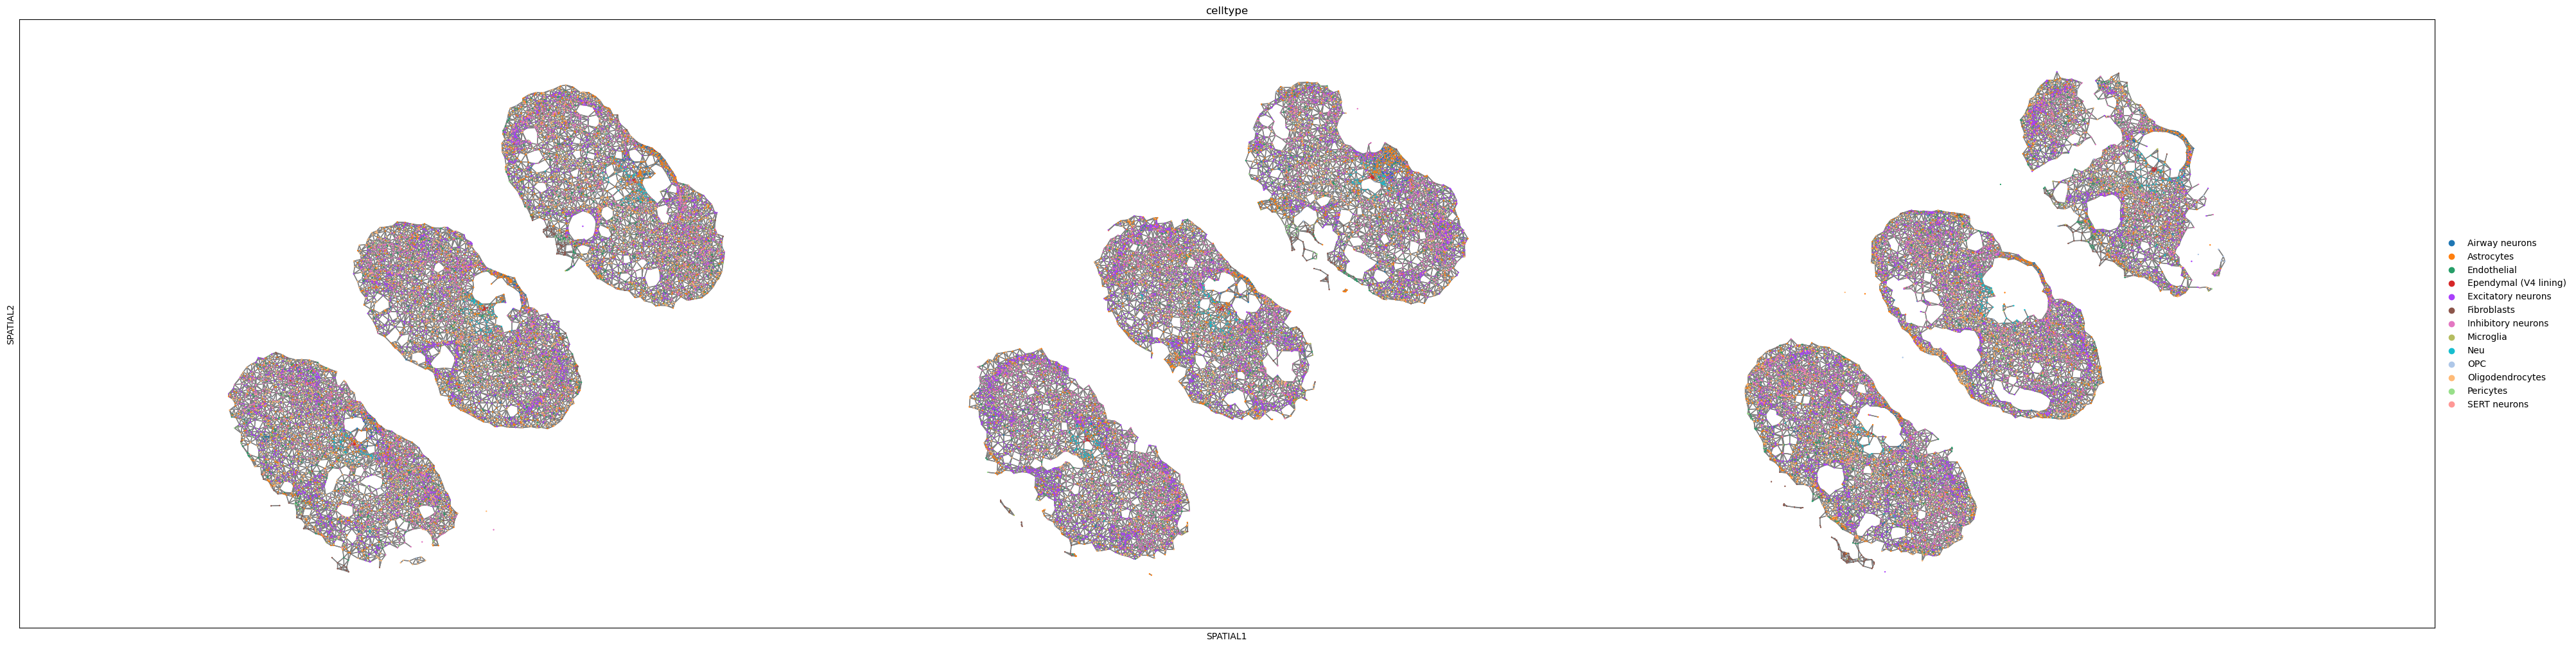

In [25]:
sq.gr.spatial_neighbors(
    adata,
    library_key=batch,
    coord_type="generic",
    delaunay=True,
    spatial_key="SPATIAL",
    percentile=99,
)
cc.gr.remove_long_links(adata)
sq.pl.spatial_scatter(
    adata,
    library_id=None,
    spatial_key="SPATIAL",
    shape=None,
    color="celltype",
    connectivity_key="spatial_connectivities",
    size=1,
    figsize=(40, 12),
)
cc.gr.aggregate_neighbors(
    adata, n_layers=3, use_rep="X_scVI", out_key="X_cellcharter", sample_key=batch
)

In [ ]:
autok = cc.tl.ClusterAutoK(n_clusters=(2, 12), max_runs=10, convergence_tol=0.001)
autok.fit(adata, use_rep="X_cellcharter")

cc.pl.autok_stability(autok)

# Check Results
(start here from script)

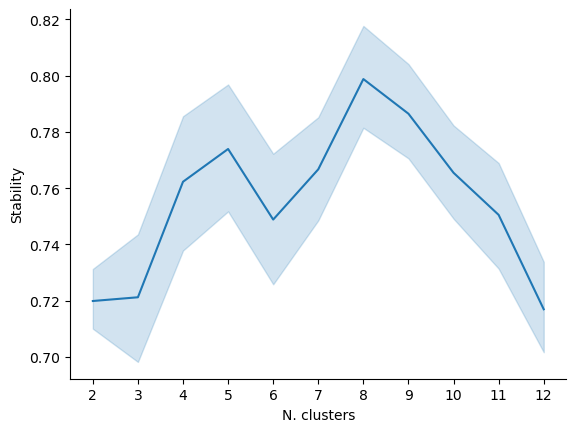

In [ ]:
savedir = DATADIR / "processed" / "external" / "cellcharter"
with open(savedir / "autok.pkl", "rb") as file:
    autok = pickle.load(file)
adata = sc.read_h5ad(savedir / "cellcharter.h5ad")
cc.pl.autok_stability(autok)

In [22]:
ks = [5, 8, 9]
for k in ks:
    adata.obs[f"cellcharter_k{k}"] = autok.predict(adata, use_rep="X_cellcharter", k=k)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


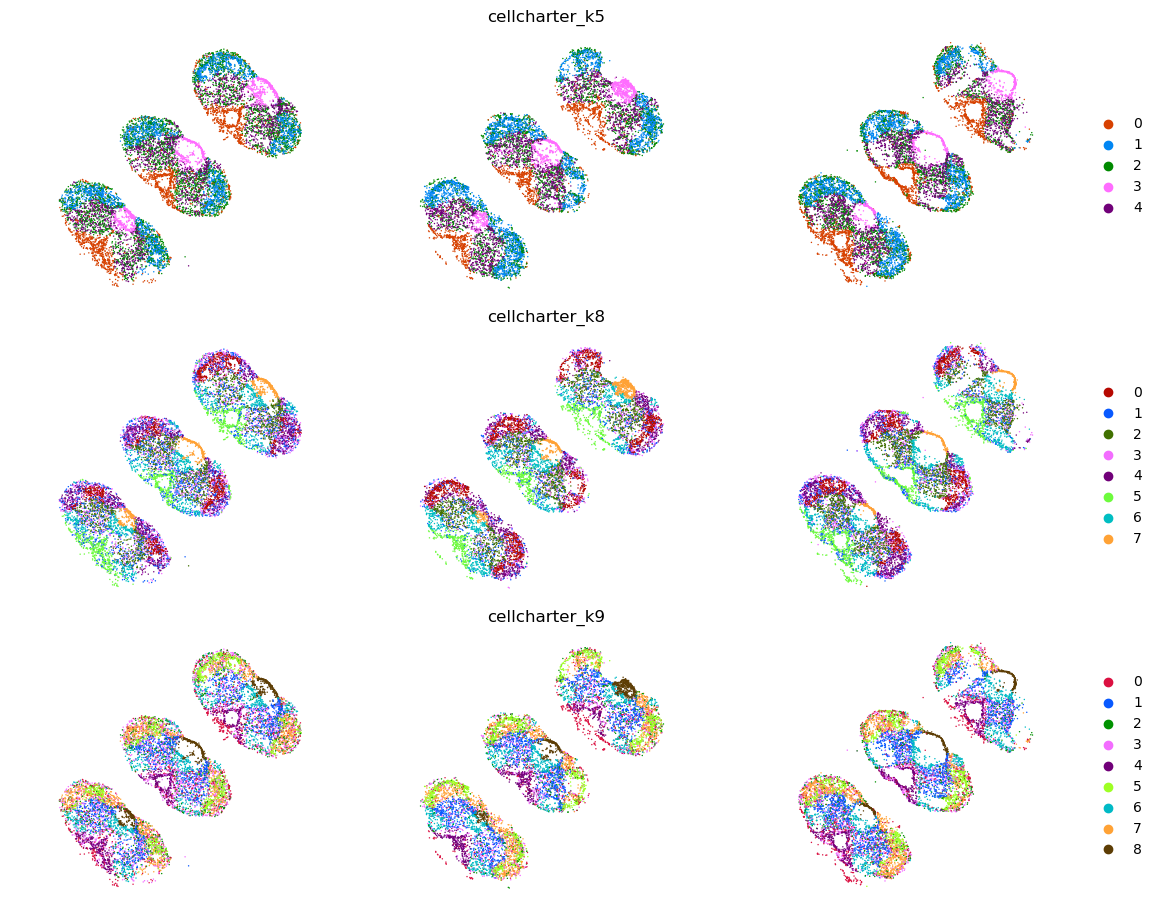

In [23]:
cluster = "cellcharter_k"

f, ax = plt.subplots(len(ks), 1, figsize=(30, 9), layout="constrained")
for n, k in enumerate(ks):
    sc.pl.spatial(
        adata,
        basis="SPATIAL",
        color=f"{cluster}{k}",
        spot_size=50,
        frameon=False,
        ax=ax[n],
        show=False,
        palette=glasbey.create_palette(len(adata.obs[f"{cluster}{k}"].cat.categories)),
    )

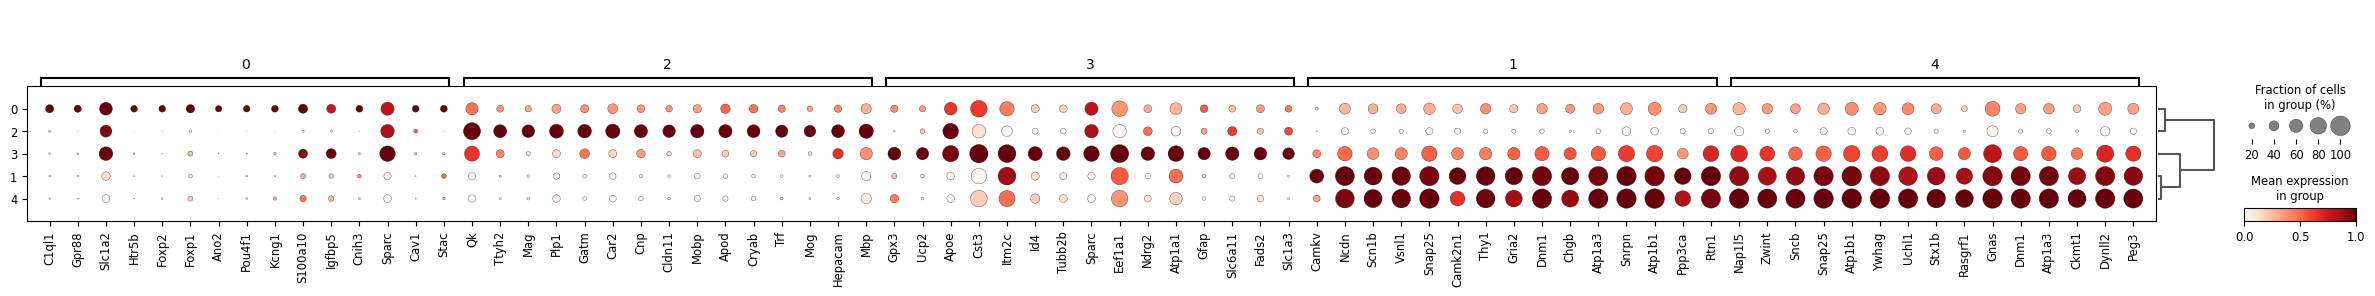

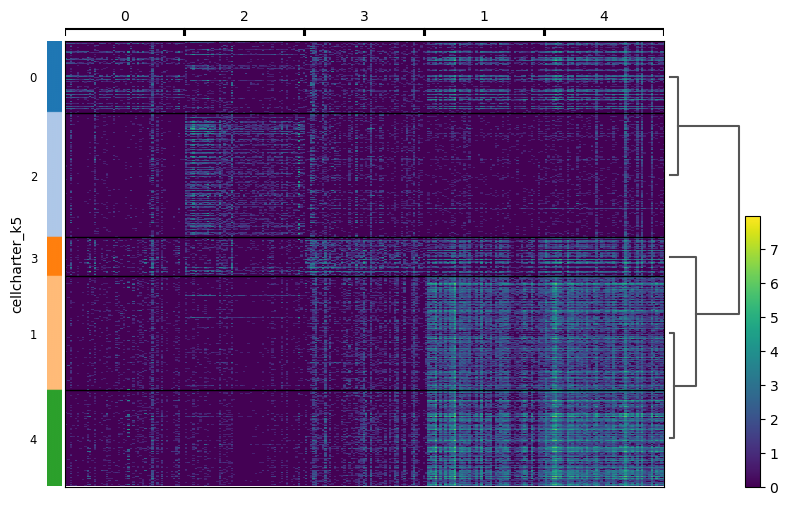

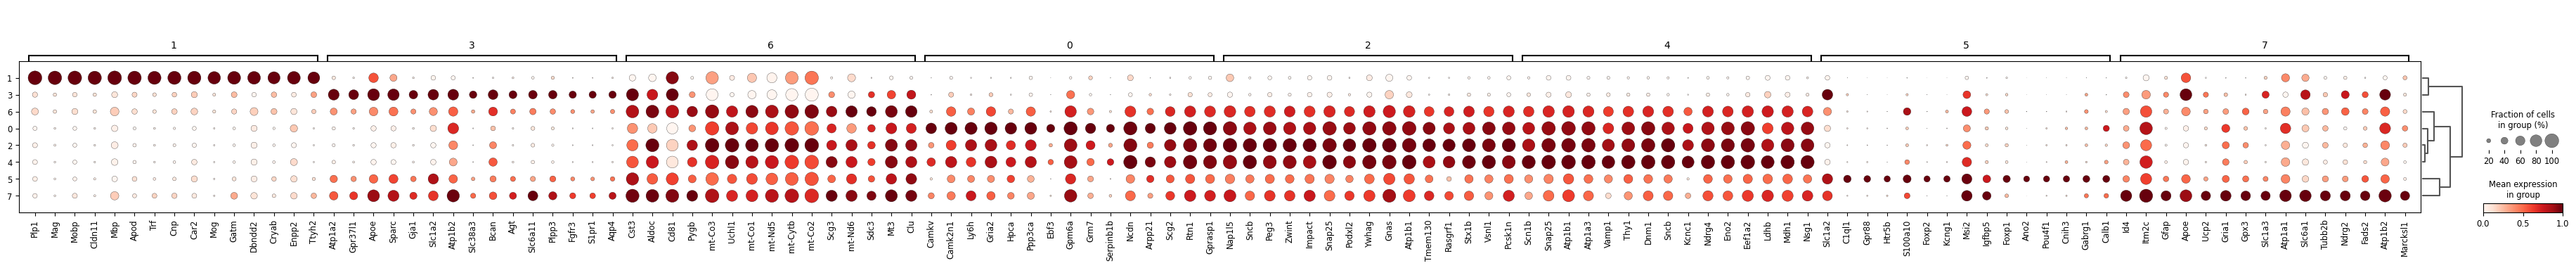

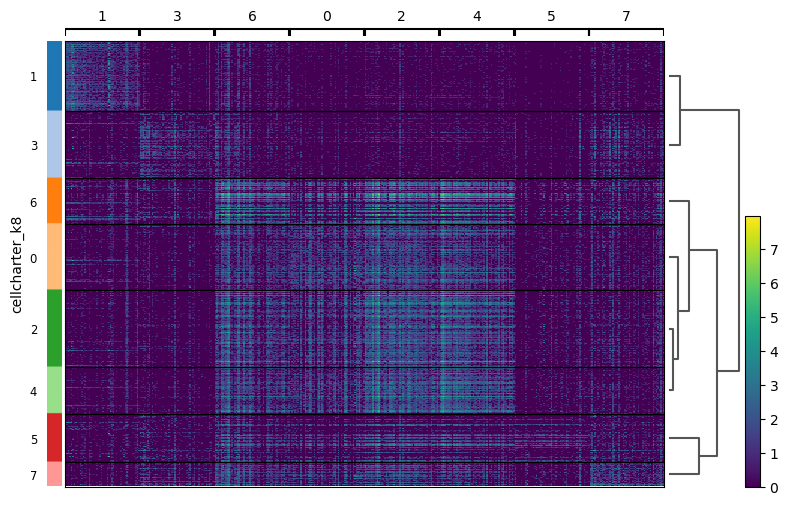

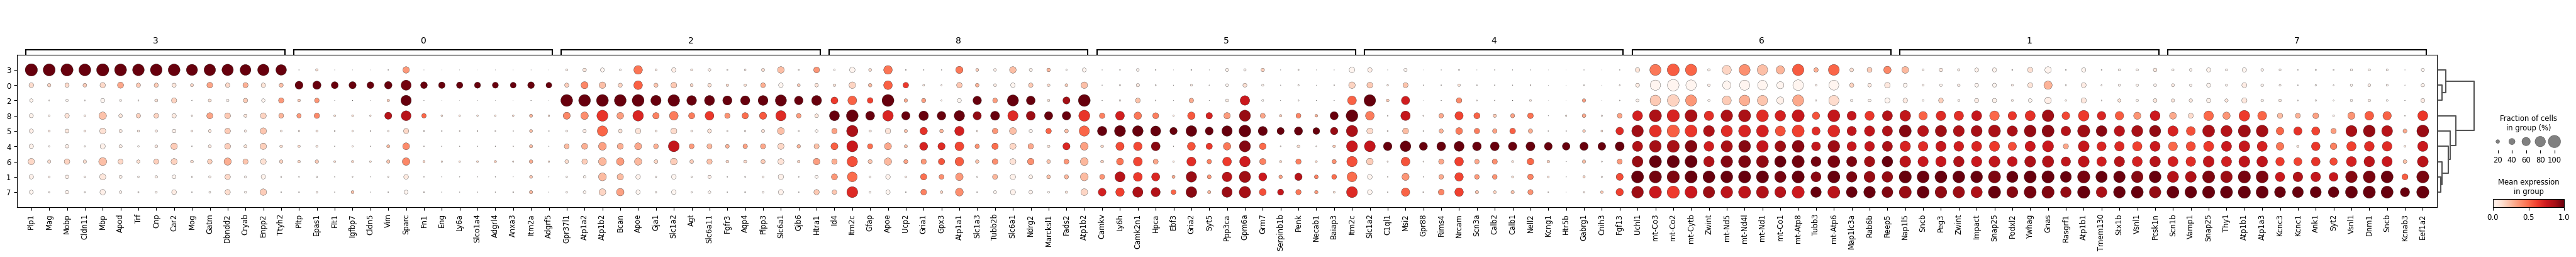

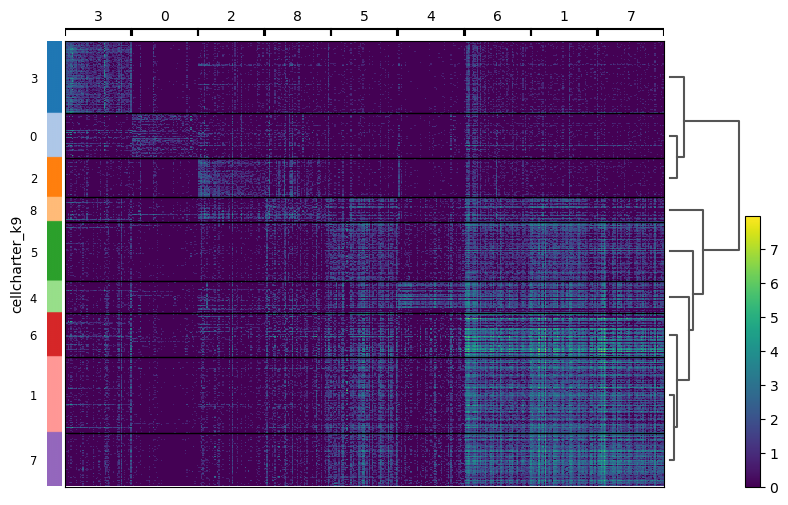

In [27]:
de_key = "DEGs_k"
runDEGs = False

for k in ks:
    if runDEGs is True:
        sc.tl.rank_genes_groups(
            adata,
            groupby=f"{cluster}{k}",
            key_added=f"{de_key}{k}",
            use_raw=False,
            layer="logcounts",
            method="wilcoxon",
        )

    sc.pl.rank_genes_groups_dotplot(
        adata,
        groupby=f"{cluster}{k}",
        key=f"{de_key}{k}",
        standard_scale="var",
        n_genes=15,
        # min_logfoldchange=2,
        # ax=ax,
    )

    sc.pl.rank_genes_groups_heatmap(
        adata,
        key=f"{de_key}{k}",
        groupby=[f"{cluster}{k}"],
        layer="logcounts",
        n_genes=50,
    )